## This notebook covers DiffuCoder papers:
- https://arxiv.org/abs/2506.20639
- https://arxiv.org/abs/2506.17298

In [ ]:
from dataclasses import dataclass
import random

@dataclass
class ToyDecodingStep:
    t: int
    decided_positions: list[int]


def toy_ar_decoding(length: int) -> list[ToyDecodingStep]:
    """
    Deterministic left-to-right AR decoding order: 0, 1, 2, ..., L-1.
    """
    steps: list[ToyDecodingStep] = []
    decided: list[int] = []
    for k in range(length):
        decided.append(k)
        steps.append(ToyDecodingStep(t=k, decided_positions=decided.copy()))
    return steps


def toy_diffusion_decoding(length: int, T: int, seed: int = 0) -> list[ToyDecodingStep]:
    """
    Toy diffusion-style decoding order:
    - Start with all positions masked.
    - At each step, randomly choose some remaining masked positions to 'resolve'.
    - Returns the cumulative set of resolved positions per step.
    """
    rng = random.Random(seed)
    remaining = list(range(length))
    resolved: list[int] = []
    steps: list[ToyDecodingStep] = []

    for t in reversed(range(1, T + 1)):  # t = T, ..., 1
        if not remaining:
            steps.append(ToyDecodingStep(t=t, decided_positions=resolved.copy()))
            continue
        # randomly resolve at least one token at each step
        n_to_resolve = max(1, len(remaining) // t)
        chosen = rng.sample(remaining, k=n_to_resolve)
        for idx in chosen:
            remaining.remove(idx)
            resolved.append(idx)
        steps.append(ToyDecodingStep(t=t, decided_positions=sorted(resolved)))

    return steps


def print_decoding_trace(steps: list[ToyDecodingStep], *, label: str) -> None:
    print(f"=== {label} ===")
    for step in steps:
        print(f"t = {step.t:2d} | resolved positions: {step.decided_positions}")


def main_toy_example():
    L = 10
    T = 5

    ar_steps = toy_ar_decoding(L)
    diff_steps = toy_diffusion_decoding(L, T, seed=42)

    print_decoding_trace(ar_steps, label="AR (auto-regressive) decoding (left-to-right)")
    print()
    print_decoding_trace(diff_steps, label="Diffusion decoding")

main_toy_example()


=== AR decoding (left-to-right) ===
t =  0 | resolved positions: [0]
t =  1 | resolved positions: [0, 1]
t =  2 | resolved positions: [0, 1, 2]
t =  3 | resolved positions: [0, 1, 2, 3]
t =  4 | resolved positions: [0, 1, 2, 3, 4]
t =  5 | resolved positions: [0, 1, 2, 3, 4, 5]
t =  6 | resolved positions: [0, 1, 2, 3, 4, 5, 6]
t =  7 | resolved positions: [0, 1, 2, 3, 4, 5, 6, 7]
t =  8 | resolved positions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
t =  9 | resolved positions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

=== Toy diffusion decoding ===
t =  5 | resolved positions: [0, 1]
t =  4 | resolved positions: [0, 1, 3, 6]
t =  3 | resolved positions: [0, 1, 3, 4, 6, 9]
t =  2 | resolved positions: [0, 1, 2, 3, 4, 6, 7, 9]
t =  1 | resolved positions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
from diffusion_lm_visualizer import MaskedDiffusionLMVisualizer

import time
from IPython.display import HTML, display, clear_output

visualizer = MaskedDiffusionLMVisualizer(
    model_name="roberta-base",
)

prompt_text = (
    "Write a short paragraph how sleep helps health.\n\n"
    "Paragraph:\n"
)

completion_text = (
    "Sleep plays a central role in physical recovery, hormone regulation, "
    "and memory consolidation. When we sleep, our immune system clears "
    "inflammation and our brain prunes and strengthens neural connections, "
    "which improves focus and mood the next day."
)

for frame_html in visualizer.visualize_schedule_on_text(
    prompt=prompt_text,
    completion_text=completion_text,
    num_steps=8,
    schedule="entropy_sink",  # or "left_to_right" / "random"
    seed=0,
):
    clear_output(wait=False)
    display(HTML(frame_html))
    time.sleep(0.7)


<video src="static/diffucoder-review/media_noising.mp4" controls width="1024">
  Your browser does not support the video tag.
</video>

<video src="static/diffucoder-review/media_denoising.mp4" controls width="1024">
  Your browser does not support the video tag.
</video>


![](static/diffucoder-review/diffucoder-architecture-v1.png)


![](static/diffucoder-review/diffucoder-inference-architecture-v1.png)

# Diffusion vs autoregressive language models

## How AR and Diffusion models generate the completion

Let a condition (prompt) be denoted by $c$ with tokens $c = (c_1, \dots, c_P)$ and the completion $o$ with tokens $o = (o_1, \dots, o_N)$.

```text
Prompt c:
"Write a Python function that adds two integers."

Completion o:
"def add(a, b): return a + b"

Positions (1-based):
  1        2       3        4        5       6       7        8        9       10    11     12  13   14   15   16  17  18       19  20  21
  ┃        ┃       ┃        ┃        ┃       ┃       ┃        ┃        ┃       ┃     ┃      ┃   ┃    ┃    ┃    ┃   ┃   ┃        ┃   ┃   ┃
 [Write]  [a]   [Python] [function] [that] [adds] [two]  [integers] [⟨SEP⟩]  [def] [add]  [(] [a]  [,]  [b]  [)]  [:] [return]  [a] [+] [b]
 └────────────────────────────── prompt c ──────────────────────────────┘   └────────────────────── completion o ───────────────────────┘
```

**Autoregressive (AR) LM.**

An AR model generates the completion left-to-right:
$$
p_{\text{AR}}(o \mid c)
= \prod_{k=1}^N p_\theta(o_k \mid c, o_{<k}) \,.
$$

Key properties:

- Causal self-attention mask, so token $k$ only attends to $c$ and $o_{<k}$.
- Training with teacher forcing: maximize the log-likelihood
  $$
  \sum_{k=1}^N \log p_\theta(o_k \mid c, o_{<k}) \,.
  $$
- Inference is inherently sequential: one token per step (or a small group via speculative decoding), which creates latency proportional to $N$.

**Diffusion LM (masked discrete diffusion).**

A masked diffusion language model defines a Markov chain over *entire sequences*
$$
x_0, x_1, \dots, x_T \,,
$$
where $x_0$ is the clean completion (same space as $o$) and $x_T$ is a fully noised / fully masked sequence.

The forward (noising) process $q$ randomly masks tokens according to a schedule:
- At each discrete timestep $t \in \{1, \dots, T\}$, a subset of token positions is replaced by a special noise symbol (e.g. `[MASK]`).
- The probability that position $k$ is masked at step $t$ is given by a schedule $p_{\text{mask}}(t)$.

The model is trained to approximate the *reverse denoising* transitions
$$
p_\theta(x_{t-1} \mid x_t, c) \,,
$$
typically parameterized via a masked language modeling head:
- Given the partially-masked sequence $x_t$ and condition $c$, the model predicts the original clean token at each position.

The training objective (simplified) is an expectation of cross-entropy losses over timesteps and masked positions:
$$
\mathcal{Loss}_{\text{diff}}(\theta)
= \mathbb{E}_{t, x_0, x_t} \bigg[
  \sum_{k \in \text{masked}(t)}
  -\log p_\theta(x_0^{(k)} \mid x_t, c, t)
\bigg] \,.
$$

**Conceptual differences (AR vs diffusion) in DiffuCoder-style models:**

- **Global vs local update.**
  - AR: each decoding step only decides *one* new token (or a small block) at the end of the sequence.
  - Diffusion: each denoising step can update *all* masked positions in parallel, so the model "looks at" the entire sequence at once and refines many tokens jointly.

- **Order of token resolution.**
  - AR: fixed left-to-right order by construction.
  - Diffusion: order is induced by the mask schedule; in principle, tokens can be decided in any position and in any order, although DiffuCoder shows that the model develops an *AR-like bias* near the prompt side ("entropy sink" and AR-ness).

- **Training signal.**
  - AR: every token is always predicted in a strictly AR context.
  - Diffusion: each token is predicted under many *partial context* configurations across timesteps, which can improve robustness and global consistency but complicates log-prob estimation.

- **Inference complexity.**
  - with $L = P + N$ total tokens (prompt + completion)
  - AR: $O(L)$ forward passes for an $L$-token completion (one pass per decoding step, though full sequence is re-encoded each time).
  - Diffusion: $O(T)$ denoising steps, each decoding *all* masked tokens. Effective complexity is $O(T \cdot L)$ inside the model, but the wall-clock latency can be much smaller than AR because all positions are processed in parallel on hardware accelerators.

- **Expressivity and inductive bias.**
  - AR strongly encourages causal reasoning and step-by-step generation.
  - Diffusion can globally plan the structure of the completion and then refine it iteratively. In DiffuCoder, this global planning is particularly helpful for respecting long-range code structure (imports, definitions, usage sites, etc.).

DiffuCoder is exactly such a masked diffusion LM specialized for code: it operates over discrete token sequences, uses a carefully designed mask schedule, and is post-trained by RL (cpGRPO) on top of the diffusion dynamics.


## Asymptotic inference cost

Let the prompt have length $P$, the completion have length $N$, and $L = P + N$ be the total context length.

Let $T$ be the number of diffusion denoising steps.

### Autoregressive LM (decoder-only with KV cache)

- Prompt prefill (encode $c$ once):
  $$
  \text{Cost}_\text{prefill} = \mathcal{O}(P^2).
  $$
- Decoding $o_1, \dots, o_N$ left-to-right **with KV caching**:
  - At step $k$ the new token only attends to the existing $P + k - 1$ tokens.
  - Total decode cost:
    $$
    \text{Cost}_\text{decode} = \sum_{k=1}^{N} \mathcal{O}(P + k)
    = \mathcal{O}(NP + N^2).
    $$
- Overall AR complexity:
  $$
  \text{Cost}_\text{AR} = \mathcal{O}\big(P^2 + NP + N^2\big) = \mathcal{O}(L^2).
  $$

**KV caching is crucial**: without it, decoding would require $N$ full length-$L$ passes, i.e. $\mathcal{O}(N L^2)$, which is *not* how modern AR LMs are implemented.

### Masked diffusion LM (DiffuCoder-style)

- Decoding operates on a fixed-length **completion state** $x_t \in \mathcal{V}^N$ for timesteps $t = T, \dots, 1$.
- At each timestep the model processes the entire pair $(c, x_t)$ and predicts token distributions at all $N$ completion positions in parallel:
  $$
  \text{Cost}_\text{step} = \mathcal{O}(L^2).
  $$
- With $T$ denoising steps:
  $$
  \text{Cost}_\text{Diffusion} = T \cdot \mathcal{O}(L^2) = \mathcal{O}(T L^2).
  $$

Thus, for comparable $(P, N, L)$, a masked diffusion LM with $T$ steps is roughly a factor of $T$ more expensive in FLOPs than AR decoding **with** KV caching:

$$
\frac{\text{Cost}_\text{Diffusion}}{\text{Cost}_\text{AR}} \approx T
$$

Parallel prediction of all positions improves wall-clock utilization on accelerators, but does not change the $\mathcal{O}(T L^2)$ scaling.


# DiffuCoder policy and cpGRPO training pipeline

## Policy and hyperparameters

We consider a **policy** to be a parameterized language model that defines a probability distribution over token sequences, conditioned on an input prompt or "condition".

* Let $\pi_\theta$ denote the **current diffusion LLM policy** with parameters $\theta$.
* Let $\pi_{\text{old}}$ denote the **behavior policy** used to sample completions for an RL update (typically a delayed copy of $\pi_\theta$).
* Each training sample consists of:

  * A **condition** $c$: the fixed, non-noised prefix (system message, problem statement, prompt template).
  * A **completion** $o = (o_1, \dots, o_N)$: the code tokens to be generated by the policy.

Key hyperparameters:


* $N$: **maximum completion length** (number of tokens in the completion region). The total sequence length is $L = P + N$, where $P$ is the prompt length.
* $T$: **number of diffusion timesteps** in the discrete schedule. At each timestep $t \in {1, \dots, T}$, a different corruption level and masking probability is applied to the completion.
* $G$: **group size** for GRPO. For each condition $c$, a group of $G$ completions ${o_i}_{i=1}^G$ is sampled and scored together.
* Reward weights and KL/clipping coefficients used in the GRPO loss.

The policy $\pi_\theta$ is a **masked diffusion language model**: at each diffusion timestep $t$ it takes as input

* the condition $c$ (kept clean by a conditional mask)
* a partially masked/noised version of the completion $x_t$
* the timestep encoding $t$

and outputs a distribution over tokens at every position in the completion region.

## DiffuCoder + coupled-GRPO training pipeline

1. **Rollout**

   * For each condition (prompt) $c$ in a batch, sample a **group** of completions
     ${o_i}_{i=1}^G$ from the current/old diffusion policy $\pi_{\text{old}}$.
   * Each completion $o_i$ is a sequence of at most $N$ tokens in the completion region.

2. **Reward**

   * For each sampled completion $o_i$, construct the full decoded program by concatenating the prompt template, the code fence header, and the completion tokens.
   * Run an **imperative scorer** consisting of:
     - a **format checker** (markdown and syntax validity, style constraints),
     - a **code executor** (run unit tests or examples and count passed tests).

   Let

   * $f_i \in [0, 1]$ denote the **format score** for completion $o_i$ (e.g., `0` for invalid markdown or syntax, intermediate values for partially valid output, `1` for fully valid),
   * $e_i \in [0, 1]$ denote the **execution score** (fraction of test cases passed by the decoded program).

   A simple linear combination yields a scalar reward
   $$
   r_i = w_{\text{exec}} \, e_i + w_{\text{fmt}} \, f_i,
   $$
   where $w_{\text{exec}}, w_{\text{fmt}} > 0$ are weighting coefficients (typically $w_{\text{exec}}$ is larger to prioritize correctness over formatting). In practice, $r_i$ may also be clipped or rescaled into a fixed range, e.g.
   $$
   r_i' = \operatorname{clip}(a \, r_i + b, \, r_{\min}, r_{\max}),
   $$
   before being passed to GRPO.

   * For a given condition $c$, the group reward vector is $\mathbf{r} = (r_1, \dots, r_G)$.

3. **Masking (coupled sampling)**

   For each completion $o_i$ in the group, we build complementary masks over positions in the completion region.

   * Sample a diffusion timestep $t \in {1, \dots, T-1}$ (or equivalently a normalized time $\tau \in (0,1)$).
   * Define its **paired timestep** $\hat t$ such that $t + \hat t = T$.
   * For the chosen $t$, define a **masking probability** $p_{\text{mask}}(t)$ according to the diffusion noise schedule.
   * For each token position $k \in {1, \dots, N}$ of completion $o_i$:

     * Sample a Bernoulli mask bit
       $M_{i,k} \sim \text{Bernoulli}(p_{\text{mask}}(t))$.

   * Define the **antithetic complementary mask**
     $\hat M_{i,k} = 1 - M_{i,k}$ for all $k$.
   * This yields, for each completion $o_i$:

     * **Mask A**: $M_i = (M_{i,1}, \dots, M_{i,N})$ at timestep $t$.
     * **Mask B**: $\hat M_i = (\hat M_{i,1}, \dots, \hat M_{i,N})$ at timestep $\hat t$.
   * Additionally, construct a **full mask** at timestep $T$ that masks all completion tokens (all bits set to 1) to form the fully noised state $x_T$.


## Bernoulli distribution

$$
P(X = 1) = p \quad\quad P(X = 0) = 1 - p
$$

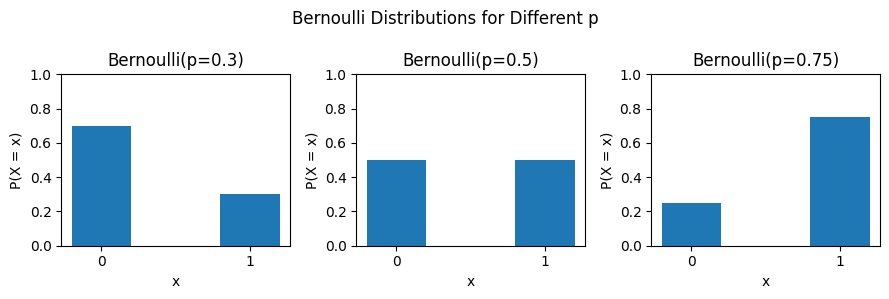

In [8]:
from typing import List
import matplotlib.pyplot as plt


def plot_bernoulli(p: float, ax: plt.Axes, title: str = "") -> None:
    """
    Plot the PMF of a Bernoulli(p) random variable on a given Axes.

    Parameters
    ----------
    p : float
        Success probability in [0, 1].
    ax : plt.Axes
        Matplotlib Axes to plot on.
    title : str
        Title for this subplot.
    """
    if not (0.0 <= p <= 1.0):
        raise ValueError(f"p must be in [0, 1], got {p}")

    x_values: List[int] = [0, 1]
    pmf_values: List[float] = [1 - p, p]

    ax.bar(x_values, pmf_values, width=0.4)
    ax.set_xticks(x_values)
    ax.set_xticklabels(["0", "1"])
    ax.set_ylim(0, 1)
    ax.set_xlabel("x")
    ax.set_ylabel("P(X = x)")
    ax.set_title(title if title else f"Bernoulli(p={p})")


def main() -> None:
    ps = [0.3, 0.5, 0.75]

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))

    for p, ax in zip(ps, axes):
        plot_bernoulli(p=p, ax=ax, title=f"Bernoulli(p={p})")

    fig.suptitle("Bernoulli Distributions for Different p", fontsize=12)
    fig.tight_layout()
    plt.show()


main()


**Practical example for $T = 11$ and antithetic timesteps.**

Assume we use the 0-based discrete timetable with $t \in \{0,1,\dots,T\}$ and $T=11$, and the antithetic pairing rule:
$$
\tilde t = T - t \quad \text{and} \quad \tau = \frac{t}{T}, \quad \tilde\tau = 1 - \tau.
$$
Then the table of discrete pairs is:

| step index $t$ | paired index $\tilde t = 11 - t$ | normalized $\tau = \tfrac{t}{11}$ | $\tilde\tau = 1 - \tau$ |
|----------------|----------------------------------|------------------------------------|---------------------------|
| 0              | 11                               | 0.0000                             | 1.0000                    |
| 1              | 10                               | 0.0909                             | 0.9091                    |
| 2              | 9                                | 0.1818                             | 0.8182                    |
| 3              | 8                                | 0.2727                             | 0.7273                    |
| 4              | 7                                | 0.3636                             | 0.6364                    |
| 5              | 6                                | 0.4545                             | 0.5455                    |
| 6              | 5                                | 0.5455                             | 0.4545                    |
| 7              | 4                                | 0.6364                             | 0.3636                    |
| 8              | 3                                | 0.7273                             | 0.2727                    |
| 9              | 2                                | 0.8182                             | 0.1818                    |
| 10             | 1                                | 0.9091                             | 0.0909                    |
| 11             | 0                                | 1.0000                             | 0.0000                    |

This is the discrete analogue of choosing a continuous $\tau \in [0,1]$ and pairing it with $\tilde\tau = 1 - \tau$.

**Toy example of Masks A and B.**

Consider a toy completion of length $N = 8$:

```text
o = ["d", "e", "f", " ", "f", "o", "o", "()"]  # "def foo()"
```

Suppose we choose $t = 3$ so that $\tau = 3/11 \approx 0.27$, and for one completion we sample a mask $M$ (Mask A) as

$$
M = [1, 0, 1, 0, 0, 1, 0, 0].
$$

Then the complementary mask (Mask B) is

$$
\hat M = 1 - M = [0, 1, 0, 1, 1, 0, 1, 1].
$$

Masks A and B are illustrated below, where `[M]` denotes a masked position (used in the loss at that timestep) and `[.]` denotes an unmasked, visible position:

```text
positions:   1    2    3    4    5    6    7    8
tokens:      d    e    f         f    o    o    ()

Mask A (t):  [M]  [.]  [M]  [.]  [.]  [M]  [.]  [.]
Mask B (t~): [.]  [M]  [.]  [M]  [M]  [.]  [M]  [M]
```

At timestep $t$, only positions with $M_k = 1$ (Mask A) are treated as masked and contribute to the loss; positions with $M_k = 0$ are visible context. At timestep $\tilde t$, the roles are swapped according to $\hat M$. Across the pair $(t, \tilde t)$, every token position is masked exactly once.



4. **Probability / loss estimation**

    For each completion $o_i$ and each of the three mask states (A at $t$, B at $\hat t$, full mask at $T$):

    * Build a masked completion state $x_t$ by:

        * inserting special `[MASK]` tokens (or equivalent) at positions where the mask bit is 1,
        * keeping the remaining completion tokens visible as context,
        * concatenating with the condition prefix $c$.

    * Feed $(c, x_t, t)$ through the diffusion policy $\pi_\theta$ to obtain logits for all positions in the completion region.
    * Convert logits to log-probabilities via a log-softmax over the vocabulary.
    * Compute the per-position cross-entropy loss **only on masked positions** (where the mask bit is 1), using the original completion tokens $o_{i,k}$ as targets.

    * Denote the per-token negative log-likelihood (cross-entropy) contributions from the three mask states as
        $\text{Loss}_t(x_t)$, $\text{Loss}_{\hat t}(x_{\hat t})$, and $\text{Loss}_T(x_T)$, where for each completion position
        $k \in \{1, \dots, N\}$ we define
        $$
        \text{Loss}_t^{(k)}(x_t)
        =
        \begin{cases}
        - \log p_\theta\big(o_{i,k} \mid s_t, t\big), & \text{if position } k \text{ is masked in } x_t, \\[4pt]
        0, & \text{otherwise,}
        \end{cases}
        $$
        and analogously
        $$
        \text{Loss}_{\hat t}^{(k)}(x_{\hat t})
        =
        \begin{cases}
        - \log p_\theta\big(o_{i,k} \mid s_{\hat t}, \hat t\big), & \text{if position } k \text{ is masked in } x_{\hat t}, \\[4pt]
        0, & \text{otherwise,}
        \end{cases}
        $$
        $$
        \text{Loss}_T^{(k)}(x_T)
        =
        \begin{cases}
        - \log p_\theta\big(o_{i,k} \mid s_T, T\big), & \text{if position } k \text{ is masked in } x_T, \\[4pt]
        0, & \text{otherwise.}
        \end{cases}
        $$
        Here $s_t = \text{concat}(c, x_t)$, $s_{\hat t} = \text{concat}(c, x_{\hat t})$, and $s_T = \text{concat}(c, x_T)$.
        We can view $\text{Loss}_t(x_t)$, $\text{Loss}_{\hat t}(x_{\hat t})$, and $\text{Loss}_T(x_T)$ as length-$N$ vectors
        collecting the per-token losses $\text{Loss}_t^{(k)}$, $\text{Loss}_{\hat t}^{(k)}$, and $\text{Loss}_T^{(k)}$.

    * Combine these contributions according to the coupled-GRPO estimator (Eq. (4) in the paper) to obtain per-token log-probability estimates for the completion:
        $$
        \log \pi_\theta(o_i)
        \approx
        -\,\frac{1}{\lambda + 1}
        \Bigg(
          \sum_{t + \hat t = T}
          \big(
            \text{Loss}_t(x_t)
            +
            \text{Loss}_{\hat t}(x_{\hat t})
          \big)
          +
          \text{Loss}_T(x_T)
        \Bigg),
        $$
        where the summation is taken token-wise and each token in the completion is masked in exactly one of the two partial passes (A or B).

**Practical example of computing log-probabilities via log-softmax over the vocabulary.**

In [6]:
from typing import Tuple
import torch
from torch import nn
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    PreTrainedTokenizerBase,
    PreTrainedModel,
)
from transformers.tokenization_utils_base import BatchEncoding


def init_model_and_tokenizer(
    model_name: str,
) -> Tuple[PreTrainedTokenizerBase, PreTrainedModel, torch.device]:
    """
    Initialize device, tokenizer, and masked language model.

    Parameters
    ----------
    model_name : str
        Name or path of the pretrained masked language model.

    Returns
    -------
    tokenizer : PreTrainedTokenizerBase
        Initialized tokenizer.
    model : PreTrainedModel
        Initialized masked language model in eval mode and moved to device.
    device : torch.device
        Device where the model is placed.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForMaskedLM.from_pretrained(model_name).to(device)
    model.eval()

    return tokenizer, model, device


def compute_masked_logprobs(
    tokenizer: PreTrainedTokenizerBase,
    model: nn.Module,
    device: torch.device,
    text_with_masks: str,
    target_tokens: list[str],
) -> Tuple[float, dict[str, float]]:
    """
    Compute the sum and per-token log-probabilities for target_tokens
    placed into [MASK] positions in text_with_masks.

    Assumes number of [MASK] tokens == len(target_tokens), and that each
    element in target_tokens corresponds to a single tokenizer token.

    Parameters
    ----------
    tokenizer : PreTrainedTokenizerBase
        Tokenizer corresponding to the model.
    model : nn.Module
        Masked language model.
    device : torch.device
        Device where the model is located.
    text_with_masks : str
        Input text containing [MASK] tokens.
    target_tokens : list[str]
        List of target tokens (token-level, not arbitrary strings).

    Returns
    -------
    total_logp : float
        Sum of log-probabilities for all target tokens.
    per_token_logps : dict[str, float]
        Per-token log-probabilities.
    """
    # Tokenize
    encoded: BatchEncoding = tokenizer(
        text_with_masks,
        return_tensors="pt",
    )
    # Move tensors to device
    encoded = BatchEncoding(
        {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in encoded.items()}
    )

    input_ids: torch.Tensor = encoded["input_ids"]        # [1, seq_len]
    attention_mask: torch.Tensor = encoded["attention_mask"]

    # Find [MASK] positions
    mask_token_id: int | None = tokenizer.mask_token_id
    if mask_token_id is None:
        raise ValueError("Tokenizer does not define a [MASK] token.")

    mask_positions: torch.Tensor = (input_ids[0] == mask_token_id).nonzero(as_tuple=False).squeeze(1)
    if mask_positions.numel() != len(target_tokens):
        raise ValueError("Number of [MASK] tokens and target_tokens must match.")

    # Forward pass
    with torch.no_grad():
        outputs: MaskedLMOutput = model(input_ids=input_ids, attention_mask=attention_mask)  # type: ignore[assignment]
        logits: torch.Tensor = outputs.logits  # [1, seq_len, vocab_size]

    # Log-softmax over vocab
    log_probs: torch.Tensor = torch.log_softmax(logits, dim=-1)  # [1, seq_len, vocab_size]

    per_token_logps: dict[str, float] = dict()
    total_logp: float = 0.0

    for pos, token_str in zip(mask_positions, target_tokens):
        # Get target token id
        target_id: int = tokenizer.convert_tokens_to_ids(token_str)
        if target_id == tokenizer.unk_token_id:
            raise ValueError(f"Target token '{token_str}' maps to [UNK]. "
                             "Ensure target_tokens are tokenizer-level tokens.")

        # log p(token_str | context, mask position)
        lp: float = float(log_probs[0, int(pos), target_id].item())
        per_token_logps[token_str] = lp
        total_logp += lp

    return total_logp, per_token_logps


def main() -> None:
    model_name = "bert-base-uncased"

    # Initialize tokenizer, model, device
    tokenizer, model, device = init_model_and_tokenizer(model_name)

    # Example: 2 masks -> 2 target tokens
    text = "I like [MASK] and [MASK]."
    targets = ["ice", "cream"]

    total_logp, per_token_logps = compute_masked_logprobs(
        tokenizer=tokenizer,
        model=model,
        device=device,
        text_with_masks=text,
        target_tokens=targets,
    )

    print(f"Text: {text}\nTargets: {targets}\n")
    print(f"Total log-prob: {total_logp:.4f}")
    for t, lp in per_token_logps.items():
        print(f"Token '{t}': log p = {lp:.4f}")


main()


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Text: I like [MASK] and [MASK].
Targets: ['ice', 'cream']

Total log-prob: -16.5033
Token 'ice': log p = -8.2056
Token 'cream': log p = -8.2977


5. **Policy gradient (GRPO)**

   For a given condition $c$ and its group of completions ${o_i}_{i=1}^G$ with rewards ${r_i}_{i=1}^G$:

   * Compute the **group baseline**:
     $$
     \bar r = \frac{1}{G} \sum_{i=1}^G r_i.
     $$
   * Define the **advantage** for each completion as
     $$
     A_i = r_i - \bar r.
     $$
   * Using the estimated log-probabilities under the current policy $\pi_\theta$ and the old policy $\pi_{\text{old}}$, compute the **importance ratio** for each completion:
     $$
     \rho_i = \exp\big( \log \pi_\theta(o_i) - \log \pi_{\text{old}}(o_i) \big).
     $$
   * Form a **clipped GRPO/PPO-style surrogate loss** over the group:
     $$
     \text{Loss}_{\text{GRPO}}(\theta) = -\mathbb{E}_i \left[ \min\big( \rho_i A_i, \operatorname{clip}(\rho_i, 1 - \epsilon, 1 + \epsilon) A_i \big) \right]
     $$
     plus a KL regularization term to keep $\pi_\theta$ close to a reference policy $\pi_{\text{ref}}$ (e.g., the instruction-tuned model).
   * Backpropagate this loss through the diffusion model to update the policy parameters $\theta$ and obtain the new policy $\pi_\theta$.

This pipeline is repeated iteratively: periodically update $\pi_{\text{old}}$ from $\pi_\theta$, resample new rollouts, and continue training with coupled-GRPO to improve `pass@1` performance on code tasks.


> `pass@1` = probability that the first completion passes all tests.

> `pass@10` = probability that at least one of the first 10 completions passes all tests.

# DiffuCoder inference (decoding algorithm)

The core idea of how DiffuCoder performs inference given a condition $c$ (e.g. a code problem plus instructions):

- Start from a **fully masked completion**.
- Run $T$ **denoising steps**.
- At each step, the model predicts token distributions for all completion positions and chooses which tokens to *commit* and which ones to remask for further refinement.

## State representation

At decoding timestep $t \in \{T, T-1, \dots, 1\}$ we maintain:

- A **completion state** $x_t = (x_t^{(1)}, \dots, x_t^{(N)})$ of length $N$:
  - Each position is either a vocabulary token or a special mask token (e.g. `[MASK]`).
- A condition $c$ (the prompt), which is kept fixed throughout decoding.

The actual sequence fed to the model at step $t$ is the **full state**
$$
s_t = \text{concat}(c, x_t)
$$
i.e. the prompt tokens $c$ followed by the (partially masked) completion tokens $x_t$. Only the completion state $x_t$ evolves with $t$; the condition $c$ does not change.

The time index $t$ is passed to the model (e.g. via a learned embedding or time conditioning) so the network can adapt its behavior across diffusion steps.

## One denoising step

Given $(c, x_t, t)$, the DiffuCoder model takes $s_t = \text{concat}(c, x_t)$ as input and outputs a logits vector for each **completion position** $k \in \{1, \dots, N\}$:
$$
\text{logits}_t^{(k)} \in \mathbb{R}^{|\mathcal{V}|}, \quad
p_\theta(\cdot \mid s_t, t) = \text{softmax}\big(\text{logits}_t^{(k)}\big)
$$
where:
  - $\mathcal{V}$ is the vocabulary
  - $|\mathcal{V}|$ is the vocabulary size

From these logits we obtain:

- Token predictions: $y_t^{(k)} = \arg\max_v p_\theta(v \mid s_t, t)$ (or a sampled token at temperature $\tau$).
- Confidence scores per position, for example:
  - Negative entropy $H_t^{(k)}$
  - Or max probability $p_{\max, t}^{(k)}$

The decoding rule follows the "entropy sink" idea:

1. **Select confident positions** where the model is "sure enough" about the token (e.g. low entropy or high $p_{\max}$)
2. **Commit** those positions by setting $x_{t-1}^{(k)} = y_t^{(k)}$
3. **Remask the rest**, i.e. $x_{t-1}^{(k)} = \text{[MASK]}$ for positions not selected

This yields a new partially-masked **completion state** $x_{t-1}$ for the next denoising step.

In symbols, for each completion position $k$:
$$
x_{t-1}^{(k)} =
\begin{cases}
y_t^{(k)}, & \text{if } \text{conf}_t^{(k)} \ge \tau_{\text{conf}}(t) \\
\text{[MASK]}, & \text{otherwise}
\end{cases}
$$
where $\text{conf}_t^{(k)}$ is a confidence metric and $\tau_{\text{conf}}(t)$ is a threshold that can depend on $t$.

## Full decoding loop

Putting this together, a simplified decoding loop for DiffuCoder is:

1. **Initialization.**
   - Choose a maximum number of steps $T$.
   - Set $x_T$ to a fully masked completion (all completion positions `[MASK]`).
2. **For $t = T, T-1, \dots, 1$:**
   1. Form the model input state $s_t = \text{concat}(c, x_t)$ and run the diffusion LM to obtain per-position logits.
   2. Compute confidence scores from the logits for completion positions.
   3. Commit confident positions, remask the rest to form $x_{t-1}$.
3. **Output.**
   - After step $t=1$, $x_0$ is (ideally) fully unmasked and used as the final completion.

The paper studies **AR-ness** of this process, i.e. how strongly the model tends to resolve tokens in an AR-like left-to-right order:

- The "entropy sink" shows that positions immediately to the right of the prompt tend to get high confidence early, so they are resolved first.
- Later steps focus more on far-right positions and lower-confidence tokens.

This explains why DiffuCoder can still be decoded in a quasi-AR fashion (e.g. focusing on the next few tokens) while remaining a global diffusion model.

## Comparison to autoregressive decoding

In AR decoding, we iteratively extend the sequence:
$$
o_{1:k} \to o_{1:k+1}
$$
by sampling from $p_\theta(o_{k+1} \mid c, o_{1:k})$.

In DiffuCoder decoding:

- The **sequence length is fixed** throughout; we are not growing the sequence.
- We repeatedly **refine** the same **completion state** $x_t$, gradually replacing `[MASK]` tokens with concrete tokens according to the diffusion schedule.
- Temperature affects both:
  - Which token is chosen at each step.
  - The *order* in which positions are resolved, via the confidence scores (high temperature reduces AR-ness and makes the order more random).

This perspective is crucial for understanding how cpGRPO later defines log-probabilities and advantages over diffusion trajectories for RL updates.
